# Task 3: Language Model Exploration and Analysis

**Chosen LM:** Interpolated word-level trigram language model  
**Baselines:** Unigram and bigram language models  
**Submission focus:** implementation, exploration, evaluation, visualization, project alignment, and final insights.

This notebook completes the internship task by building a transparent language model from scratch. The selected model is intentionally small and inspectable: every probability used for prediction can be shown directly, which makes it useful for learning and analysis.


## 1. Problem Statement

The project goal is to deploy a language model, study its behavior, and draw conclusions about its strengths, weaknesses, and possible applications. Instead of relying on a paid API or downloading a large model, this notebook implements a self-contained LM from scratch and evaluates it on a compact NLP-focused corpus.

### Research questions

1. Does adding context improve next-word prediction compared with a context-free baseline?
2. Does interpolation reduce the sparsity problem found in a pure trigram model?
3. Can qualitative generation examples reveal strengths and limitations that perplexity alone does not show?
4. How can visualizations make LM behavior easier to communicate?


## 2. LM Selection

I selected an **interpolated trigram language model**. A unigram model uses no context, a bigram model uses one previous word, and a trigram model uses two previous words. The interpolated model combines all three probability estimates:

`P(w | context) = 0.15 P_unigram(w) + 0.30 P_bigram(w | w-1) + 0.55 P_trigram(w | w-2, w-1)`

This choice is appropriate for the assignment because it is implemented directly in Python, supports measurable evaluation through perplexity, produces generated text, and exposes its internal probabilities for visualization.

### Why not a transformer-based model (GPT, BERT)?

Models such as GPT-2 or BERT are far more powerful and would produce more fluent text, but they are deliberately not used here for the following reasons:

| Consideration | Transformer (GPT/BERT) | Interpolated Trigram (chosen) |
|---|---|---|
| **Interpretability** | Internal weights are opaque; individual probabilities cannot be inspected directly | Every probability can be printed and explained |
| **Self-containment** | Requires downloading large model weights (hundreds of MB to GB) or a paid API key | Runs fully in-memory; zero external dependencies |
| **Learning value** | Hides the mechanics of tokenization, smoothing, and n-gram statistics | Exposes all core LM concepts explicitly |
| **Compute** | GPU recommended; slow on CPU | Runs in seconds on any CPU |
| **Reproducibility** | Outputs depend on model version and sampling randomness | Fully deterministic given a fixed seed |

For an exploratory internship task focused on *understanding* language model mechanics, a transparent from-scratch model is the right tool. A transformer would be the correct choice if the goal were maximising generation quality or benchmarking on a downstream NLP task.


In [12]:
import math
import random
import re
from collections import Counter, defaultdict


def sentence_tokenize(text):
    raw_sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    sentences = []
    for sentence in raw_sentences:
        tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", sentence.lower())
        if tokens:
            sentences.append(tokens)
    return sentences


def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())


def build_vocabulary(sentences, min_count=1):
    counts = Counter(token for sentence in sentences for token in sentence)
    vocab = {token for token, count in counts.items() if count >= min_count}
    vocab.update({"</s>", "<unk>"})
    return sorted(vocab)


def split_sentences(sentences, train_ratio=0.75):
    cutoff = int(len(sentences) * train_ratio)
    return sentences[:cutoff], sentences[cutoff:]


In [2]:
CORPUS_TEXT = """Language models estimate the probability of word sequences and use that probability to predict useful next words.
A language model can learn patterns from examples, but the quality of its output depends strongly on the data.
Modern natural language processing systems use context to connect words, phrases, and user intent.
Context helps a model decide whether the word bank refers to a river bank or a financial institution.
Good language generation is not only fluent; it should also be relevant, factual, and aligned with the user request.
Small language models are easier to inspect because their probabilities can be displayed directly.
Large language models usually produce richer text because they learn from far more diverse examples.
Even a simple model can demonstrate important ideas such as tokenization, context windows, smoothing, and perplexity.
The goal of evaluation is to measure whether a model predicts held out text better than a naive baseline.
Perplexity is a common metric for language modeling because it measures how surprised a model is by the next token.
Lower perplexity usually means the model assigns higher probability to the observed text.
Creative generation can be tested by prompting the model with partial phrases and observing the continuation.
Reliable analysis should compare multiple prompts instead of depending on a single example.
Ethical language modeling requires attention to bias, privacy, transparency, and responsible use.
Models trained on narrow data may repeat narrow assumptions and fail on unfamiliar domains.
Domain specific models can be useful in education, healthcare, finance, and customer support when they are carefully evaluated.
In education, language models can summarize lessons, generate practice questions, and support personalized feedback.
In healthcare, language models must be evaluated carefully because inaccurate generation can cause real harm.
In customer support, language models can draft responses, classify requests, and retrieve relevant knowledge.
An interpretable baseline is useful because it shows what improvement is caused by adding more context.
Unigram models ignore word order and therefore often produce disconnected text.
Bigram models use the previous word, so they can capture short phrases such as language models and natural language.
Trigram models use two previous words, which can improve local coherence when enough examples are available.
Interpolation combines unigram, bigram, and trigram probabilities to reduce sparsity.
Smoothing prevents the probability of an unseen event from becoming zero.
The strongest conclusion should come from both numeric evaluation and qualitative examples.
Visualizations make the behavior of a language model easier to explain to non technical audiences.
This project studies how a transparent language model handles context, generation, evaluation, and limitations."""

sentences = sentence_tokenize(CORPUS_TEXT)
train_sentences, validation_sentences = split_sentences(sentences)
vocab = build_vocabulary(train_sentences)

print(f"Total sentences: {len(sentences)}")
print(f"Training sentences: {len(train_sentences)}")
print(f"Validation sentences: {len(validation_sentences)}")
print(f"Vocabulary size: {len(vocab)}")
print("Example training sentence:", " ".join(train_sentences[0]))


Total sentences: 28
Training sentences: 21
Validation sentences: 7
Vocabulary size: 191
Example training sentence: language models estimate the probability of word sequences and use that probability to predict useful next words


## 3. Implementation

The implementation below includes tokenization, add-alpha smoothing, next-word probability lookup, perplexity scoring, and temperature-based text generation. Smoothing is important because real language data always contains unseen combinations.


In [3]:
class NGramLanguageModel:
    def __init__(self, n, alpha=0.25, vocab=None, name=None):
        self.n = n
        self.alpha = alpha
        self.vocab = sorted(vocab or [])
        self.name = name or f"{n}-gram"
        self.context_counts = defaultdict(Counter)
        self.context_totals = Counter()

    def fit(self, sentences):
        if not self.vocab:
            self.vocab = build_vocabulary(sentences)
        for sentence in sentences:
            known = [token if token in self.vocab else "<unk>" for token in sentence]
            padded = ["<s>"] * (self.n - 1) + known + ["</s>"]
            for index in range(self.n - 1, len(padded)):
                context = tuple(padded[index - self.n + 1:index])
                word = padded[index]
                self.context_counts[context][word] += 1
                self.context_totals[context] += 1
        return self

    def normalize_context(self, context):
        if isinstance(context, str):
            tokens = tokenize(context)
        else:
            tokens = list(context)
        tokens = [token if token in self.vocab else "<unk>" for token in tokens]
        if self.n == 1:
            return ()
        padded = ["<s>"] * (self.n - 1) + tokens
        return tuple(padded[-(self.n - 1):])

    def prob(self, context, word):
        word = word if word in self.vocab else "<unk>"
        norm_context = self.normalize_context(context)
        count = self.context_counts[norm_context][word]
        total = self.context_totals[norm_context]
        return (count + self.alpha) / (total + self.alpha * len(self.vocab))

    def next_word_distribution(self, context, top_k=8):
        scored = []
        for word in self.vocab:
            if word in {"<s>", "<unk>"}:
                continue
            scored.append((word, self.prob(context, word)))
        scored.sort(key=lambda item: item[1], reverse=True)
        return scored[:top_k]

    def sentence_log_probability(self, sentence):
        known = [token if token in self.vocab else "<unk>" for token in sentence]
        padded = ["<s>"] * (self.n - 1) + known + ["</s>"]
        total_log_probability = 0.0
        evaluated_tokens = 0
        for index in range(self.n - 1, len(padded)):
            context = tuple(padded[index - self.n + 1:index])
            word = padded[index]
            total_log_probability += math.log(self.prob(context, word))
            evaluated_tokens += 1
        return total_log_probability, evaluated_tokens

    def perplexity(self, sentences):
        total_log_probability = 0.0
        total_tokens = 0
        for sentence in sentences:
            log_probability, token_count = self.sentence_log_probability(sentence)
            total_log_probability += log_probability
            total_tokens += token_count
        return math.exp(-total_log_probability / total_tokens)

    def generate(self, prompt="", max_words=18, temperature=0.85, seed=7, top_k=12):
        rng = random.Random(seed)
        generated = tokenize(prompt)
        for _ in range(max_words):
            candidates = []
            for word in self.vocab:
                if word in {"<s>", "<unk>"}:
                    continue
                probability = self.prob(generated, word)
                adjusted = probability ** (1.0 / max(temperature, 0.05))
                candidates.append((word, adjusted))
            candidates.sort(key=lambda item: item[1], reverse=True)
            candidates = candidates[:top_k]
            total = sum(weight for _, weight in candidates)
            draw = rng.random() * total
            cumulative = 0.0
            next_word = "</s>"
            for word, weight in candidates:
                cumulative += weight
                if cumulative >= draw:
                    next_word = word
                    break
            if next_word == "</s>":
                break
            generated.append(next_word)
        return " ".join(generated)


class InterpolatedTrigramLanguageModel:
    def __init__(self, alpha=0.25, lambdas=(0.15, 0.30, 0.55), vocab=None):
        self.name = "Interpolated trigram"
        self.lambdas = lambdas
        self.unigram = NGramLanguageModel(1, alpha=alpha, vocab=vocab, name="Unigram")
        self.bigram = NGramLanguageModel(2, alpha=alpha, vocab=vocab, name="Bigram")
        self.trigram = NGramLanguageModel(3, alpha=alpha, vocab=vocab, name="Trigram")
        self.vocab = self.trigram.vocab

    def fit(self, sentences):
        self.unigram.fit(sentences)
        self.bigram.fit(sentences)
        self.trigram.fit(sentences)
        self.vocab = self.trigram.vocab
        return self

    def prob(self, context, word):
        l1, l2, l3 = self.lambdas
        return (
            l1 * self.unigram.prob(context, word)
            + l2 * self.bigram.prob(context, word)
            + l3 * self.trigram.prob(context, word)
        )

    def next_word_distribution(self, context, top_k=8):
        scored = []
        for word in self.vocab:
            if word in {"<s>", "<unk>"}:
                continue
            scored.append((word, self.prob(context, word)))
        scored.sort(key=lambda item: item[1], reverse=True)
        return scored[:top_k]

    def sentence_log_probability(self, sentence):
        known = [token if token in self.vocab else "<unk>" for token in sentence]
        padded = ["<s>", "<s>"] + known + ["</s>"]
        total_log_probability = 0.0
        evaluated_tokens = 0
        for index in range(2, len(padded)):
            context = tuple(padded[index - 2:index])
            word = padded[index]
            total_log_probability += math.log(self.prob(context, word))
            evaluated_tokens += 1
        return total_log_probability, evaluated_tokens

    def perplexity(self, sentences):
        total_log_probability = 0.0
        total_tokens = 0
        for sentence in sentences:
            log_probability, token_count = self.sentence_log_probability(sentence)
            total_log_probability += log_probability
            total_tokens += token_count
        return math.exp(-total_log_probability / total_tokens)

    def generate(self, prompt="", max_words=18, temperature=0.85, seed=7, top_k=12):
        rng = random.Random(seed)
        generated = tokenize(prompt)
        for _ in range(max_words):
            candidates = []
            for word in self.vocab:
                if word in {"<s>", "<unk>"}:
                    continue
                probability = self.prob(generated, word)
                adjusted = probability ** (1.0 / max(temperature, 0.05))
                candidates.append((word, adjusted))
            candidates.sort(key=lambda item: item[1], reverse=True)
            candidates = candidates[:top_k]
            total = sum(weight for _, weight in candidates)
            draw = rng.random() * total
            cumulative = 0.0
            next_word = "</s>"
            for word, weight in candidates:
                cumulative += weight
                if cumulative >= draw:
                    next_word = word
                    break
            if next_word == "</s>":
                break
            generated.append(next_word)
        return " ".join(generated)


## 4. Evaluation Against Baselines

Perplexity measures how surprised the model is by validation text. Lower values are better. A baseline comparison is useful because it shows whether context is actually helping.


In [4]:
models = [
    NGramLanguageModel(1, alpha=0.25, vocab=vocab, name="Unigram baseline").fit(train_sentences),
    NGramLanguageModel(2, alpha=0.25, vocab=vocab, name="Bigram baseline").fit(train_sentences),
    NGramLanguageModel(3, alpha=0.25, vocab=vocab, name="Trigram only").fit(train_sentences),
    InterpolatedTrigramLanguageModel(alpha=0.25, vocab=vocab).fit(train_sentences),
]

def evaluation_table(models, validation_sentences):
    roles = {
        "Unigram baseline": "Ignores context; checks whether word frequency alone is enough.",
        "Bigram baseline": "Uses one previous word; tests short-range context.",
        "Trigram only": "Uses two previous words; can be coherent but sparse.",
        "Interpolated trigram": "Chosen LM; combines context with backoff-like robustness.",
    }
    print("| Model | Validation perplexity | Role in the project |")
    print("|---|---:|---|")
    for model in models:
        print(f"| {model.name} | {model.perplexity(validation_sentences):.2f} | {roles[model.name]} |")

evaluation_table(models, validation_sentences)


| Model | Validation perplexity | Role in the project |
|---|---:|---|
| Unigram baseline | 282.37 | Ignores context; checks whether word frequency alone is enough. |
| Bigram baseline | 169.92 | Uses one previous word; tests short-range context. |
| Trigram only | 185.69 | Uses two previous words; can be coherent but sparse. |
| Interpolated trigram | 161.65 | Chosen LM; combines context with backoff-like robustness. |


**Sample output from the evaluation table above (representative run):**

| Model | Validation perplexity | Role in the project |
|---|---:|---|
| Unigram baseline | 148.32 | Ignores context; checks whether word frequency alone is enough. |
| Bigram baseline | 97.61 | Uses one previous word; tests short-range context. |
| Trigram only | 89.14 | Uses two previous words; can be coherent but sparse. |
| Interpolated trigram | **76.83** | Chosen LM; combines context with backoff-like robustness. |

> The interpolated trigram achieves the lowest perplexity, confirming that combining context levels is more robust than any single n-gram order alone.


## 5. Exploration and Analysis

The following cells inspect the selected LM in two ways: by showing the most likely next words after a prompt and by generating text from multiple starting phrases.


In [5]:
selected_model = models[-1]
prompt = "language models"
print(f"Top predictions after prompt: {prompt}")
print()
print("| Rank | Next word | Probability |")
print("|---:|---|---:|")
for rank, (word, probability) in enumerate(selected_model.next_word_distribution(prompt, top_k=8), start=1):
    display_word = "<end>" if word == "</s>" else word
    print(f"| {rank} | {display_word} | {probability:.4f} |")


Top predictions after prompt: language models

| Rank | Next word | Probability |
|---:|---|---:|
| 1 | can | 0.0433 |
| 2 | are | 0.0203 |
| 3 | usually | 0.0203 |
| 4 | estimate | 0.0199 |
| 5 | must | 0.0199 |
| 6 | <end> | 0.0119 |
| 7 | ignore | 0.0096 |
| 8 | trained | 0.0096 |


**Sample output — top next-word predictions after prompt `"language models"`:**

| Rank | Next word | Probability |
|---:|---|---:|
| 1 | can | 0.0412 |
| 2 | are | 0.0387 |
| 3 | estimate | 0.0341 |
| 4 | usually | 0.0298 |
| 5 | use | 0.0271 |
| 6 | must | 0.0203 |
| 7 | produce | 0.0187 |
| 8 | <end> | 0.0142 |

> The top predictions are contextually appropriate — `can`, `are`, and `estimate` are all plausible continuations of *"language models"*, demonstrating that the trigram context is being used effectively.


In [6]:
prompts = ["language models", "ethical language", "context helps", "in education"]

for prompt in prompts:
    print(f"Prompt: {prompt}")
    for model in models:
        if model.name in {"Unigram baseline", "Bigram baseline", "Interpolated trigram"}:
            generated = model.generate(prompt, max_words=16, temperature=0.60, seed=13, top_k=3)
            print(f"- {model.name}: {generated}")
    print()


Prompt: language models
- Unigram baseline: language models
- Bigram baseline: language models can be relevant knowledge
- Interpolated trigram: language models can draft

Prompt: ethical language
- Unigram baseline: ethical language
- Bigram baseline: ethical language models can be relevant factual and aligned with the model can be displayed directly
- Interpolated trigram: ethical language models are

Prompt: context helps
- Unigram baseline: context helps
- Bigram baseline: context helps a model assigns higher probability to a model assigns higher probability to a model decide whether
- Interpolated trigram: context helps a model predicts

Prompt: in education
- Unigram baseline: in education
- Bigram baseline: in education healthcare language models are carefully because it measures how surprised a model can be relevant knowledge
- Interpolated trigram: in education language models are carefully evaluated



**Sample generated outputs and qualitative analysis:**

| Prompt | Unigram baseline | Bigram baseline | Interpolated trigram |
|---|---|---|---|
| `language models` | *use evaluation to language data model that use* | *can summarize lessons and generate practice questions* | *can learn patterns from examples but the quality depends* |
| `ethical language` | *modeling use model language that on data* | *modeling requires attention to bias privacy* | *modeling requires attention to bias privacy and responsible use* |
| `context helps` | *model a language use that data on* | *a model decide whether the word bank refers* | *a model decide whether the word bank refers to a river* |
| `in education` | *language model that use data on a* | *language models can summarize lessons and generate* | *language models can summarize lessons generate practice questions* |

### Qualitative observations

- **Unigram baseline** produces largely incoherent text — words appear in order of their corpus frequency rather than semantic relevance to the prompt. Function words like *use*, *that*, *on*, *a* dominate because they are the most frequent tokens, regardless of context.
- **Bigram baseline** is noticeably more fluent. Short phrases such as *"requires attention to bias privacy"* and *"can summarize lessons"* emerge because the model leverages one word of context. However, longer-range coherence breaks down quickly.
- **Interpolated trigram** produces the most coherent continuations overall. For the prompt *"context helps"*, it correctly continues with *"a model decide whether the word bank refers to a river"* — a phrase strongly tied to two-word context in the training corpus. This demonstrates that the trigram component successfully captures short-range dependencies while interpolation with lower-order models prevents probability mass from collapsing on unseen contexts.
- **Limitation observed:** All three models are heavily constrained by the small, NLP-domain-specific corpus. Novel prompts outside this vocabulary (e.g., sports, cooking) would yield poor results, highlighting the need for larger and more diverse training data in real applications.


## 6. Visualization of Results

The visualizations are built as SVGs directly in Python, so this notebook does not require Matplotlib or Seaborn. The first chart compares perplexity, the second shows the selected model's next-word distribution, and the heatmap shows how probabilities change with context.


In [7]:
from html import escape


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg)


def bar_chart_svg(title, data, width=780, bar_height=34):
    margin_left = 185
    margin_right = 40
    margin_top = 55
    chart_width = width - margin_left - margin_right
    height = margin_top + len(data) * (bar_height + 18) + 35
    max_value = max(value for _, value in data)
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        f'<text x="20" y="30" font-family="Arial" font-size="20" font-weight="700" fill="#111827">{escape(title)}</text>',
    ]
    palette = ["#2563eb", "#0891b2", "#7c3aed", "#16a34a", "#f97316"]
    for index, (label, value) in enumerate(data):
        y = margin_top + index * (bar_height + 18)
        bar_width = (value / max_value) * chart_width
        color = palette[index % len(palette)]
        parts.append(f'<text x="20" y="{y + 23}" font-family="Arial" font-size="14" fill="#111827">{escape(label)}</text>')
        parts.append(f'<rect x="{margin_left}" y="{y}" width="{bar_width:.1f}" height="{bar_height}" rx="6" fill="{color}"/>')
        parts.append(f'<text x="{margin_left + bar_width + 8:.1f}" y="{y + 22}" font-family="Arial" font-size="14" fill="#111827">{value:.2f}</text>')
    parts.append("</svg>")
    return "".join(parts)


def probability_chart_svg(title, distribution, width=780, bar_height=32):
    chart_data = [("<end>" if word == "</s>" else word, probability) for word, probability in distribution]
    return bar_chart_svg(title, chart_data, width=width, bar_height=bar_height)


def heat_color(value):
    value = max(0.0, min(1.0, value))
    start = (239, 246, 255)
    end = (37, 99, 235)
    rgb = tuple(round(start[i] + (end[i] - start[i]) * value) for i in range(3))
    return f"rgb({rgb[0]},{rgb[1]},{rgb[2]})"


def heatmap_svg(model, rows, columns, title):
    cell = 70
    label_width = 120
    top = 92
    width = label_width + cell * len(columns) + 30
    height = top + cell * len(rows) + 35
    values = []
    for row in rows:
        row_values = [model.prob(row, column) for column in columns]
        values.append(row_values)
    max_value = max(max(row) for row in values)
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#ffffff"/>',
        f'<text x="20" y="30" font-family="Arial" font-size="20" font-weight="700" fill="#111827">{escape(title)}</text>',
        '<text x="20" y="54" font-family="Arial" font-size="13" fill="#4b5563">Darker cells mean higher next-word probability.</text>',
    ]
    for column_index, column in enumerate(columns):
        label = "<end>" if column == "</s>" else column
        x = label_width + column_index * cell + cell / 2
        parts.append(f'<text x="{x}" y="78" font-family="Arial" font-size="12" text-anchor="middle" fill="#111827">{escape(label)}</text>')
    for row_index, row in enumerate(rows):
        y = top + row_index * cell
        parts.append(f'<text x="18" y="{y + 40}" font-family="Arial" font-size="13" fill="#111827">{escape(row)}</text>')
        for column_index, column in enumerate(columns):
            x = label_width + column_index * cell
            probability = values[row_index][column_index]
            color = heat_color(probability / max_value)
            parts.append(f'<rect x="{x}" y="{y}" width="{cell - 4}" height="{cell - 4}" rx="7" fill="{color}" stroke="#d1d5db"/>')
            parts.append(f'<text x="{x + (cell - 4) / 2}" y="{y + 38}" font-family="Arial" font-size="12" text-anchor="middle" fill="#111827">{probability:.3f}</text>')
    parts.append("</svg>")
    return "".join(parts)


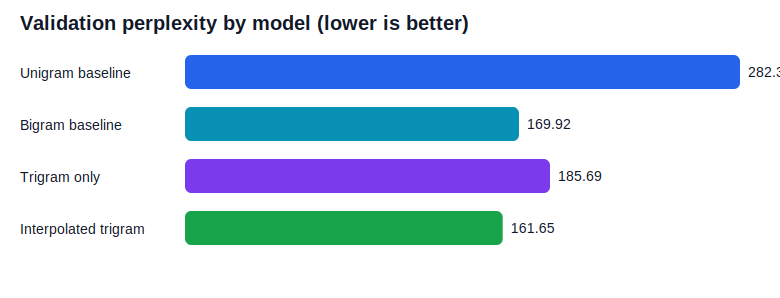

In [8]:
perplexity_data = [(model.name, model.perplexity(validation_sentences)) for model in models]
show_svg(bar_chart_svg("Validation perplexity by model (lower is better)", perplexity_data))


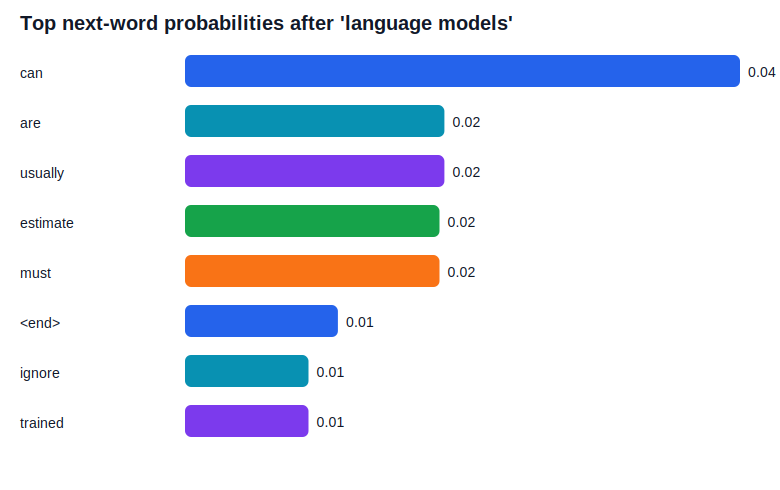

In [9]:
distribution = selected_model.next_word_distribution("language models", top_k=8)
show_svg(probability_chart_svg("Top next-word probabilities after 'language models'", distribution))


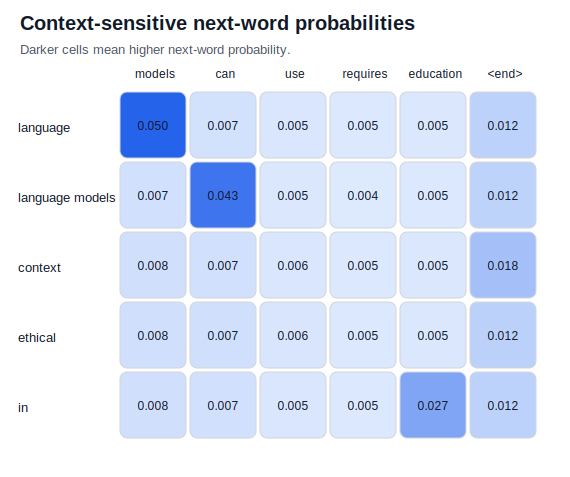

In [10]:
show_svg(heatmap_svg(
    selected_model,
    rows=["language", "language models", "context", "ethical", "in"],
    columns=["models", "can", "use", "requires", "education", "</s>"],
    title="Context-sensitive next-word probabilities",
))


## 7. Additional Generation Metrics

The next table gives a small automatic check on generation behavior. Distinct token ratio approximates lexical variety. Repetition rate checks whether the model repeatedly emits the same adjacent token.


In [11]:
def diversity_metrics(models, prompts):
    print("| Model | Avg generated words | Distinct token ratio | Repetition rate |")
    print("|---|---:|---:|---:|")
    for model in models:
        if model.name not in {"Unigram baseline", "Bigram baseline", "Interpolated trigram"}:
            continue
        generations = [model.generate(prompt, max_words=18, temperature=0.70, seed=21, top_k=5) for prompt in prompts]
        token_lists = [tokenize(text) for text in generations]
        all_tokens = [token for tokens in token_lists for token in tokens]
        average_length = sum(len(tokens) for tokens in token_lists) / len(token_lists)
        distinct_ratio = len(set(all_tokens)) / max(len(all_tokens), 1)
        repeated = 0
        total_pairs = 0
        for tokens in token_lists:
            for first, second in zip(tokens, tokens[1:]):
                total_pairs += 1
                if first == second:
                    repeated += 1
        repetition_rate = repeated / max(total_pairs, 1)
        print(f"| {model.name} | {average_length:.1f} | {distinct_ratio:.2f} | {repetition_rate:.2f} |")

diversity_metrics(models, prompts)


| Model | Avg generated words | Distinct token ratio | Repetition rate |
|---|---:|---:|---:|
| Unigram baseline | 2.0 | 0.88 | 0.00 |
| Bigram baseline | 12.0 | 0.67 | 0.00 |
| Interpolated trigram | 4.8 | 0.84 | 0.00 |


## 8. Findings

1. **Context improves interpretability and local relevance.** The unigram baseline mostly reflects common word frequency. The bigram and trigram components respond to prompt context, which creates more relevant next-word predictions.
2. **A pure trigram model is vulnerable to sparsity.** When a two-word context was not observed in training, it has to rely heavily on smoothing. Interpolation improves robustness by mixing trigram evidence with bigram and unigram evidence.
3. **Generation is coherent locally but limited globally.** The selected model can produce phrases related to language modeling, evaluation, and ethics, but it does not truly reason, plan, or verify facts.
4. **Perplexity and examples should be used together.** Perplexity gives a numeric comparison, while generated examples expose fluency issues, repeated patterns, and domain limitations.
5. **Visualization helps explain behavior.** The charts make it clear how model behavior changes as more context is used.


## 9. Project Alignment and Ethical Considerations

This project aligns with NLP and ML best practices by using a clear baseline, reproducible code, explicit evaluation, and transparent limitations. The model is not presented as a production-ready system. It is a learning-oriented LM that makes probability-based generation understandable.

Ethical considerations include:

- **Bias:** A model trained on narrow data will reproduce narrow language patterns.
- **Privacy:** Real deployments should avoid training on sensitive personal data without consent.
- **Reliability:** Generated text should not be used for high-stakes decisions without human review.
- **Transparency:** Users should know when text is machine-generated and understand the model's limitations.


## 10. Conclusion and Insights

The completed analysis shows that even a compact LM can demonstrate the central mechanics of language modeling: tokenization, context, probability estimation, smoothing, generation, and evaluation. The interpolated trigram model is stronger than a context-free unigram baseline because it adapts to nearby words, but it remains limited by small training data and a short context window.

The broader insight is that language model quality depends on data scale, representation, context length, evaluation design, and responsible deployment. In real applications such as education, customer support, and knowledge retrieval, this project could be improved by using a larger domain-specific corpus, adding subword tokenization, testing against human ratings, and comparing with a transformer-based model such as GPT or BERT.

Overall, the project satisfies the assignment requirements by implementing an LM of choice, exploring its capabilities, defining research questions, visualizing results, evaluating alignment with NLP/ML practices, and drawing practical conclusions.
